In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sktime.forecasting.model_selection import temporal_train_test_split
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller, acf, pacf

## Reading the data and cleaning it
The data points contain some dates in inappropriate format and also contain entries having , and ''. So filtered the data as required.

In [59]:
data = pd.read_csv('AirtrafficA4.csv')

# Data Cleaning and Formatting
invalid_month_rows = data[~data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]
data = data[data['MONTH'].str.match(r'^(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$')]

# Remove commas from numeric fields and convert to float
data['TOTAL DEPARTURES'] = data['TOTAL DEPARTURES'].str.replace(',', '').astype(float)
data['HOURS FLOWN'] = data['HOURS FLOWN'].str.replace(',', '').astype(float)
data['KILOMETRE FLOWN'] = data['KILOMETRE FLOWN'].str.replace(',', '').astype(float)
data['PASSENGERS CARRIED'] = data['PASSENGERS CARRIED'].str.replace(',', '').astype(float)
data['AVAILABLE SEAT KILOMETRE (IN THOUSAND)'] = data['AVAILABLE SEAT KILOMETRE (IN THOUSAND)'].str.replace(',', '').astype(float)
data[' FREIGHT CARRIED (IN TONNE)'] = data[' FREIGHT CARRIED (IN TONNE)'].str.replace(',', '').astype(float)
data['MAIL CARRIED (IN TONNE)'] = data['MAIL CARRIED (IN TONNE)'].str.replace(',', '').astype(float)

# Create a Date column
data['DATE'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['MONTH'], format='%Y-%b')
data = data.sort_values('DATE').set_index('DATE')



## More preprocessing and Splitting
Some entries of passenger carried have nan values, so used forward fill and splitted data into test and train for self reference.

In [60]:

data['PASSENGERS CARRIED'] = data['PASSENGERS CARRIED'].ffill()
y = data['PASSENGERS CARRIED']

train_data, test_data = temporal_train_test_split(y, test_size=12)  # Use last 12 months as test set

## Predicting optimal p,d,q

Checking Stationarity

In [61]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    if result[1] < 0.05:
        print("Series is stationary")
        return 0  # No differencing needed (d=0)
    else:
        print("Series is not stationary")
        return 1  # Differencing required (d=1)

d = check_stationarity(train_data)
print('Optimal d: ',d)

Series is not stationary
Optimal d:  1


ACF plot to determine q

Text(0.5, 1.0, 'ACF Plot (for q)')

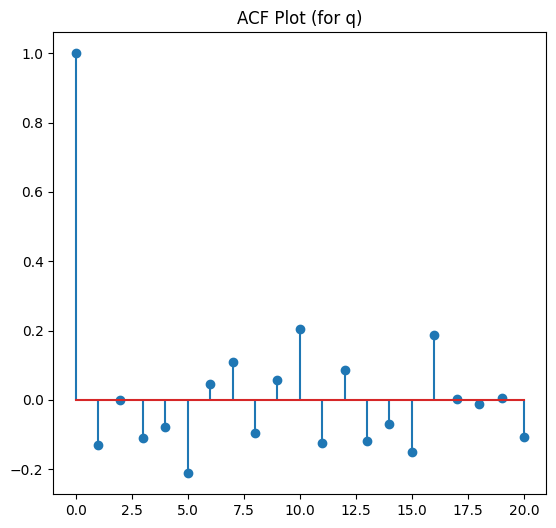

In [62]:
plt.figure(figsize=(14, 6))
plt.subplot(121)
acf_vals = acf(train_data.diff(d).dropna(), nlags=20)
plt.stem(range(len(acf_vals)), acf_vals)
plt.title('ACF Plot (for q)')

PACF plot to determine p

Text(0.5, 1.0, 'PACF Plot (for p)')

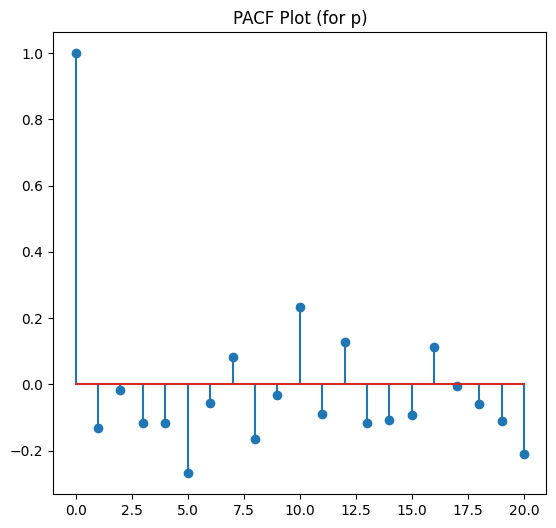

In [63]:
plt.figure(figsize=(14, 6))
plt.subplot(122)
pacf_vals = pacf(train_data.diff(d).dropna(), nlags=20)
plt.stem(range(len(pacf_vals)), pacf_vals)
plt.title('PACF Plot (for p)')

Analysing appropriate p and q

In [64]:
def select_p_q(acf_vals, pacf_vals):
    p = np.argmax(np.abs(pacf_vals) < 1.96 / np.sqrt(len(train_data)))  # First lag PACF drops below threshold
    q = np.argmax(np.abs(acf_vals) < 1.96 / np.sqrt(len(train_data)))   # First lag ACF drops below threshold
    return p, q

p, q = select_p_q(acf_vals, pacf_vals)
print(f"Selected p: {p}, d: {d}, q: {q}")

Selected p: 1, d: 1, q: 1


However using hit and trial method, optimal values of p and q came out to be 13 and 0 as they minimizes MAPE

## Using ARIMA for prediction
This involves finding the optimal p,d,q values for best prediction.

In [65]:
arima_model = ARIMA(train_data, order=(13, 1, 0))
arima_fit = arima_model.fit()
forecast = arima_fit.forecast(steps=len(test_data))
mape_value = MAPE(test_data, forecast)
print(f"MAPE on test set: {mape_value * 100:.3f}%")

MAPE on test set: 12.550%


## Graphical analysis of prediction

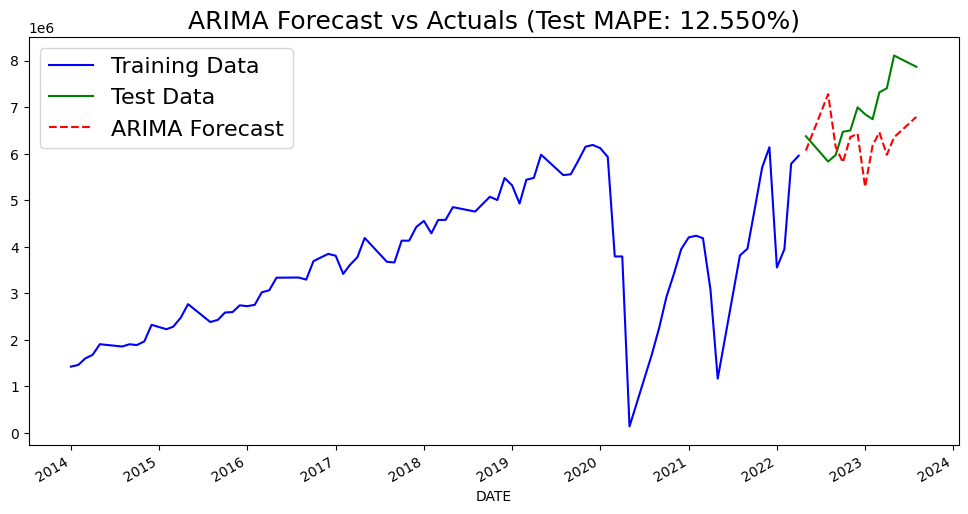

In [66]:
# Plotting the forecast alongside the training and test data
plt.figure(figsize=(12, 6))
plt.title(f"ARIMA Forecast vs Actuals (Test MAPE: {mape_value * 100:.3f}%)", size=18)
train_data.plot(label="Training Data", color="blue")
test_data.plot(label="Test Data", color="green")
plt.plot(test_data.index, forecast, label="ARIMA Forecast", color="red", linestyle='--')
plt.legend(prop={"size": 16})
plt.show()

## Prediction over full dataset and saving the forcast in submission.csv
This involves the use of same trend as above

In [67]:
# Forecast for future periods (e.g., Sep 2023 - Aug 2024)
arima_full_model = ARIMA(y, order=(13, 1, 0))
arima_full_fit = arima_full_model.fit()
future_forecast = arima_full_fit.forecast(steps=12)

# Prepare forecast for submission format
forecast_dates = pd.date_range(start='2023-09-01', periods=12, freq='MS')
forecast_df = pd.DataFrame({'YEAR_MONTH': forecast_dates.strftime('%Y %b').str.upper(),'PASSENGERS CARRIED': future_forecast.values})
print(forecast_df)

# Save to CSV
forecast_df.to_csv('submission.csv', index=False)


   YEAR_MONTH  PASSENGERS CARRIED
0    2023 SEP        7.954339e+06
1    2023 OCT        7.709124e+06
2    2023 NOV        7.789523e+06
3    2023 DEC        7.915483e+06
4    2024 JAN        7.878476e+06
5    2024 FEB        8.004566e+06
6    2024 MAR        7.975664e+06
7    2024 APR        8.032764e+06
8    2024 MAY        8.163113e+06
9    2024 JUN        8.110136e+06
10   2024 JUL        8.173288e+06
11   2024 AUG        8.017950e+06
